# MG-GAT Interpretability Analysis
**Report Findings Notebook**

Calls functions from `analyze.py`. Run cells top-to-bottom after training is complete.

| Analysis | What it shows |
|---|---|
| 1. NIG Sparsity | Does attention truly filter noisy neighbors? |
| 2. Feature Relevance (FR) | Which features drive neighbor importance? |
| 3. Transparency Validation | Are NIG weights consistent with feature similarity? |
| 4. Case Study | Single recommendation explained with NIG + FR |
| 5. Ablation | NIG-on vs NIG-off RMSE comparison |


In [1]:
import os, sys, json, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
warnings.filterwarnings('ignore')

sys.path.insert(0, '.')

from torch.utils.data import DataLoader
from loaddata import load_mggat_data
from models import MGGATRecommender
from analyze import (
    load_trained_model,
    analyze_nig_sparsity,
    extract_and_plot_fr,
    validate_nig_transparency,
    explain_one_recommendation,
    ablation_nig_vs_uniform,
    ablation_component_contribution
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('figures', exist_ok=True)
print(f"Device: {device}")
print("All imports OK ✓")


Device: cuda
All imports OK ✓


## 0. Load Trained Model

In [2]:
model, S_u, S_b, eu, eb, train_ds, tune_ds, test_ds, params = load_trained_model(
    model_path='best_model.pth',
    hyperparams_path='best_hyperparameters.json',
    device=device
)
test_loader  = DataLoader(test_ds,  batch_size=2048, shuffle=False)
tune_loader  = DataLoader(tune_ds,  batch_size=2048, shuffle=False)

DATA_DIR = 'dataset/PA/'
df_user_feat = pd.read_csv(os.path.join(DATA_DIR, 'user_features.csv'))
df_item_feat = pd.read_csv(os.path.join(DATA_DIR, 'item_features.csv'))

implicit_dim = params.get("implicit_dim", 20)

implicit_names_user = [f'implicit_u_{i}' for i in range(implicit_dim)]
implicit_names_biz  = [f'implicit_b_{i}' for i in range(implicit_dim)]

feature_names_user = list(df_user_feat.columns) + implicit_names_user
feature_names_biz  = list(df_item_feat.columns) + implicit_names_biz

print(f"Users:             {S_u.shape[0]:,}  |  User feature dim:  {S_u.shape[1]}")
print(f"Businesses:        {S_b.shape[0]:,}  |  Biz feature dim:   {S_b.shape[1]}")
print(f"User feature names (first 5):  {feature_names_user[:5]}")
print(f"Biz  feature names (first 5):  {feature_names_biz[:5]}")


Loading explicit data...
Loading network graphs...
Business graphs loaded: 4
num_i_graphs 4
num_u_graphs 1
Model loaded from best_model.pth
Params: {'latent_dim': 61, 'final_dim': 81, 'lr': 0.00048455983301301704, 'weight_decay': 0.0020783731536803234, 'theta_1': 0.007568749976674576, 'activation_in': 'relu', 'activation_out': 'tanh', 'implicit_dim': 4}
Users:             76,864  |  User feature dim:  36
Businesses:        10,966  |  Biz feature dim:   1227
User feature names (first 5):  ['compliments: hot', 'compliments: more', 'compliments: profile', 'compliments: cute', 'compliments: list']
Biz  feature names (first 5):  ['categories: & Probates', 'categories: Active Life: ATV Rentals/Tours', 'categories: Food: Acai Bowls', 'categories: Shopping: Fashion: Accessories', 'categories: Professional Services: Accountants']


In [3]:
print("omega:", model.item_gat.omega.detach().cpu().numpy())
print("a_self norm:", np.linalg.norm(model.item_gat.a_self.detach().cpu().numpy()))
print("a_nb norm:",   np.linalg.norm(model.item_gat.a_nb.detach().cpu().numpy()))
for i, e in enumerate(eb):
    print(f"item graph {i}: {e.shape[1]} edges")

omega: [ 0.08020832  0.53692234  0.13771635 -0.00154484]
a_self norm: 0.18715401
a_nb norm: 0.62422246
item graph 0: 109660 edges
item graph 1: 109660 edges
item graph 2: 90804 edges
item graph 3: 109660 edges


### Model Parameter Overview

In [4]:
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable:,}")
print()
print("Key interpretability parameters:")
print(f"  user_gat.a_self  shape: {model.user_gat.a_self.shape}")
print(f"  user_gat.a_nb    shape: {model.user_gat.a_nb.shape}")
print(f"  user_gat.W_1     shape: {model.user_gat.W_1.weight.shape}")
print(f"  item_gat.omega   values: {model.item_gat.omega.detach().cpu().numpy().round(4)}")
print(f"  item_gat.a_self  shape: {model.item_gat.a_self.shape}")
print(f"  item_gat.a_nb    shape: {model.item_gat.a_nb.shape}")


Total parameters:     7,373,841
Trainable parameters: 7,373,841

Key interpretability parameters:
  user_gat.a_self  shape: torch.Size([1, 61])
  user_gat.a_nb    shape: torch.Size([1, 61])
  user_gat.W_1     shape: torch.Size([61, 36])
  item_gat.omega   values: [ 0.0802  0.5369  0.1377 -0.0015]
  item_gat.a_self  shape: torch.Size([1, 61])
  item_gat.a_nb    shape: torch.Size([1, 61])


---
## NIG Sparsity
**Question:** Does NIG truly filter noisy neighbors, or does it behave like uniform attention?

**Method:** Compute Gini coefficient and top-1 weight share for each node's attention distribution.
- Gini = 0 → perfectly uniform (no filtering)
- Gini → 1 → all weight on one neighbor (maximum filtering)


In [5]:
nig_results = analyze_nig_sparsity(
    model, S_u, S_b, eu, eb, device,
    num_samples=2000,
    output_dir='figures'
)



──────────────────────────────────────────────────
[NIG Sparsity] User side  (n_nodes = 1400)
  Gini coefficient:  mean=0.1752  median=0.1118
  Top-1 weight share: 0.3494  vs. uniform=0.2384
  Top-3 weight share: 0.6852
  NIG selectivity ratio (top-1 / uniform): 1.47x
  Figure saved → figures/nig_sparsity_user.png

──────────────────────────────────────────────────
[NIG Sparsity] Business side  (n_nodes = 1736)
  Gini coefficient:  mean=0.1839  median=0.1593
  Top-1 weight share: 0.2215  vs. uniform=0.1498
  Top-3 weight share: 0.4920
  NIG selectivity ratio (top-1 / uniform): 1.48x
  Figure saved → figures/nig_sparsity_business.png


=== User NIG Sparsity ===


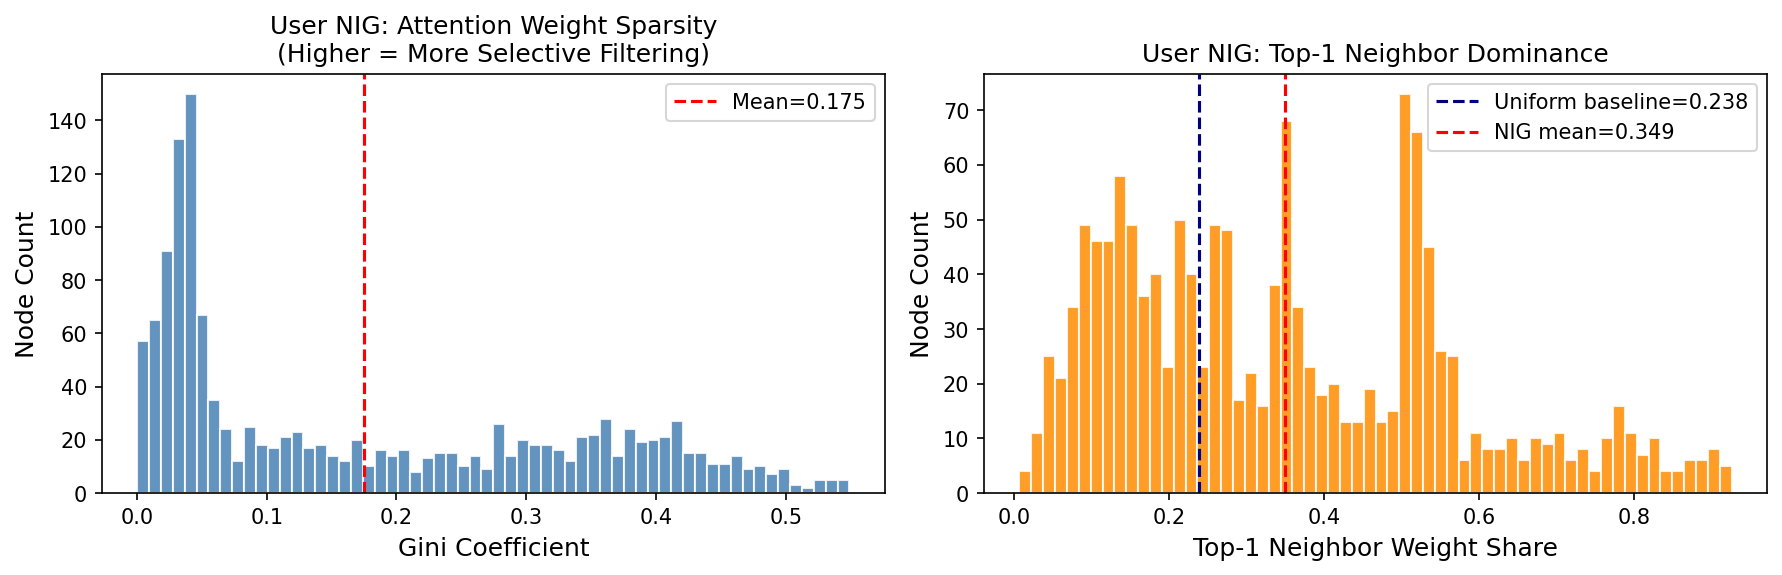


=== Business NIG Sparsity ===


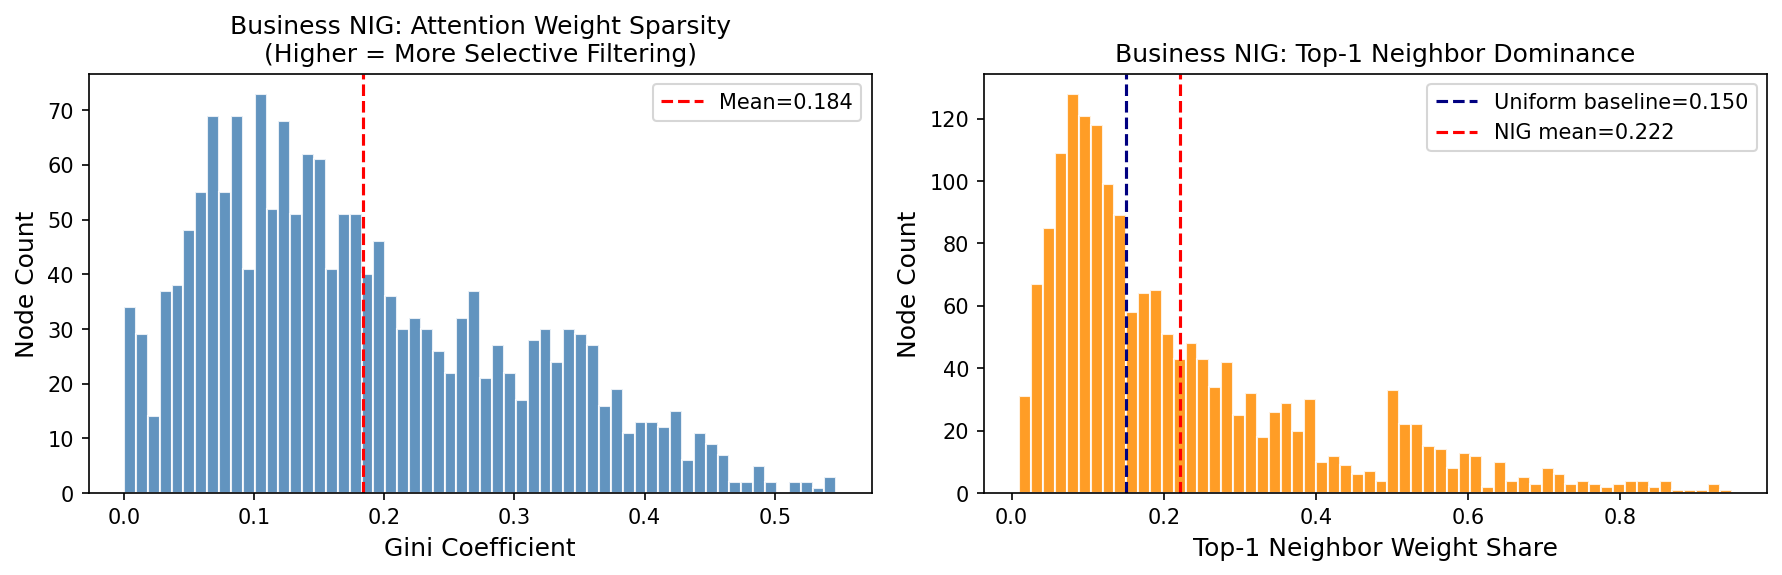

In [6]:
# Display the saved figures inline
from IPython.display import Image, display

print("=== User NIG Sparsity ===")
display(Image('figures/nig_sparsity_user.png'))
print("\n=== Business NIG Sparsity ===")
display(Image('figures/nig_sparsity_business.png'))


In [7]:
# Summary statistics for report table
for side in ['User', 'Business']:
    r = nig_results[side]
    print(f"[{side}]")
    print(f"  Gini:           mean={r['gini'].mean():.4f}  median={np.median(r['gini']):.4f}  std={r['gini'].std():.4f}")
    print(f"  Top-1 share:    mean={r['top1'].mean():.4f}")
    print(f"  Top-3 share:    mean={r['top3'].mean():.4f}")
    print(f"  Uniform top-1:  {r['uniform_top1']:.4f}")
    ratio = r['top1'].mean() / r['uniform_top1']
    print(f"  Selectivity ratio (NIG / Uniform): {ratio:.2f}x")
    print()


[User]
  Gini:           mean=0.1752  median=0.1118  std=0.1577
  Top-1 share:    mean=0.3494
  Top-3 share:    mean=0.6852
  Uniform top-1:  0.2384
  Selectivity ratio (NIG / Uniform): 1.47x

[Business]
  Gini:           mean=0.1839  median=0.1593  std=0.1175
  Top-1 share:    mean=0.2215
  Top-3 share:    mean=0.4920
  Uniform top-1:  0.1498
  Selectivity ratio (NIG / Uniform): 1.48x



---
## Analysis 2: Feature Relevance (FR)
**Question:** Which auxiliary features drive neighbor importance (NIG)?

**Method:** Extract FR weights directly from model parameters (Definition 2 in paper).

`FR_focal = a_self^T @ W1`  
`FR_neighbor = (Σ ω_g) * a_nb^T @ W1`

Compare with paper's claim for PA: *"good for groups, reservations, table service, good for kids, alcohol"*


In [8]:
all_fr = extract_and_plot_fr(
    model,
    feature_names_user=feature_names_user,
    feature_names_biz=feature_names_biz,
    top_k=20,
    output_dir='figures'
)



──────────────────────────────────────────────────
[FR] Top-20 User Features driving NIG:
  # 1 (+)  elite_2015                                     FR=0.3424
  # 2 (+)  elite_2014                                     FR=0.3131
  # 3 (+)  elite_2017                                     FR=0.2711
  # 4 (+)  elite_2012                                     FR=0.2686
  # 5 (+)  elite_2013                                     FR=0.2605
  # 6 (+)  elite_2011                                     FR=0.2493
  # 7 (+)  elite_2018                                     FR=0.2331
  # 8 (+)  elite_2016                                     FR=0.2247
  # 9 (+)  yelping_since_day                              FR=0.1990
  #10 (+)  implicit_u_3                                   FR=0.1841
  #11 (+)  yelping_since_month                            FR=0.1706
  #12 (-)  implicit_u_2                                   FR=0.1202
  #13 (+)  yelping_since_year                             FR=0.0990
  #14 (+)  elite_2010    

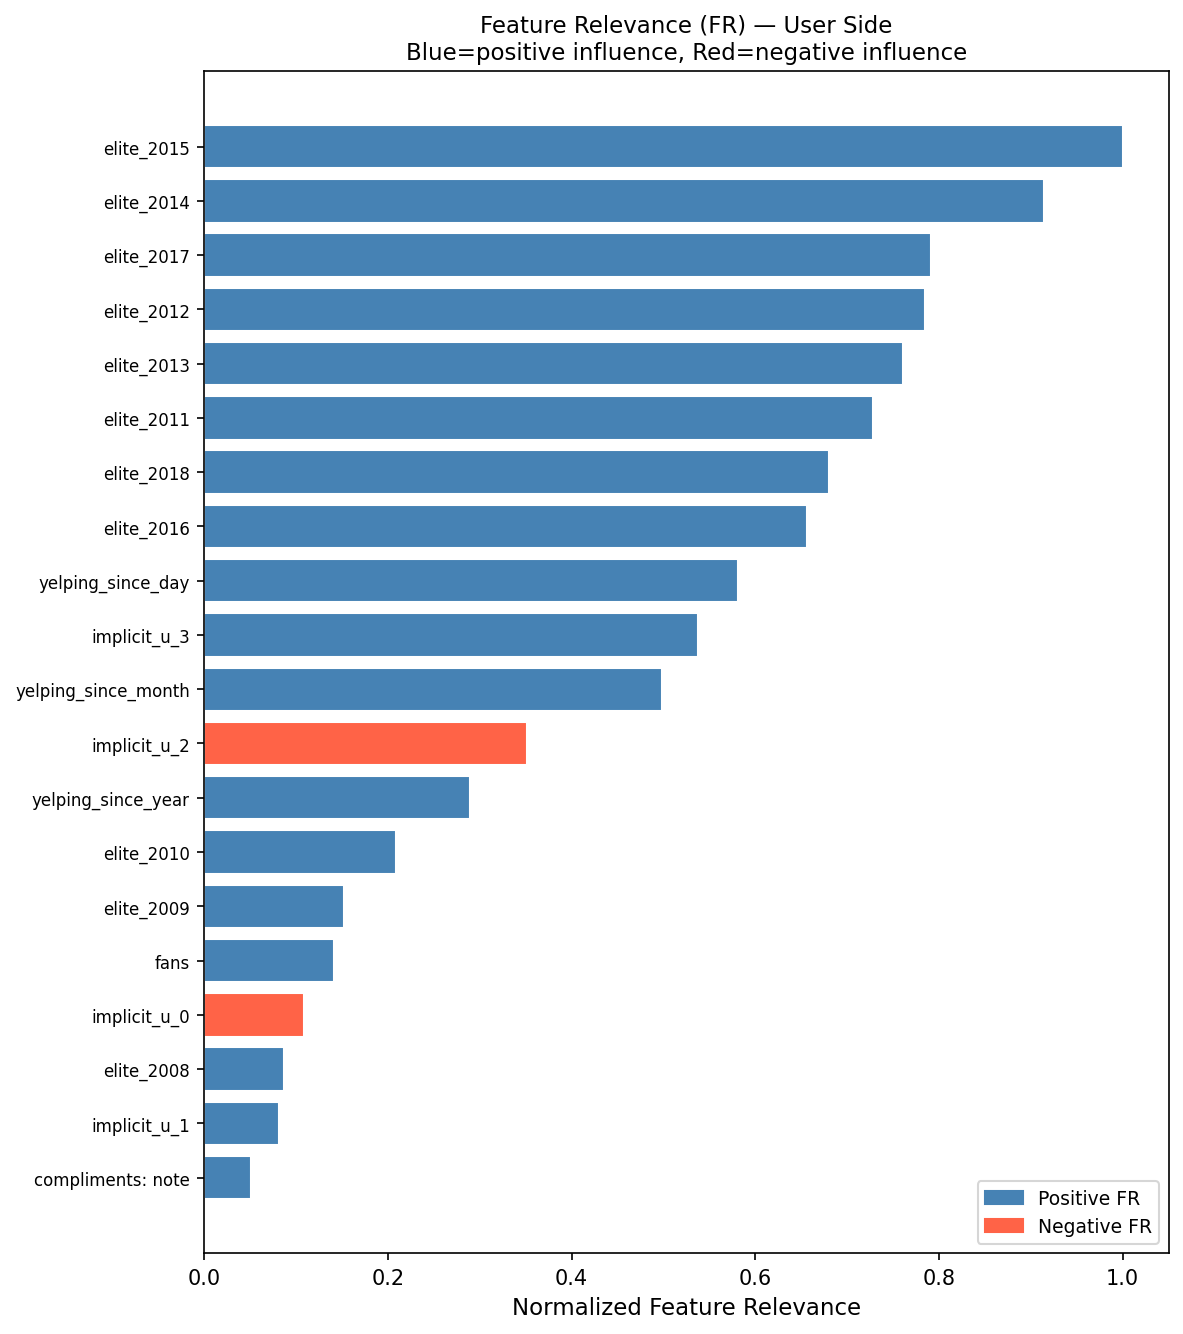

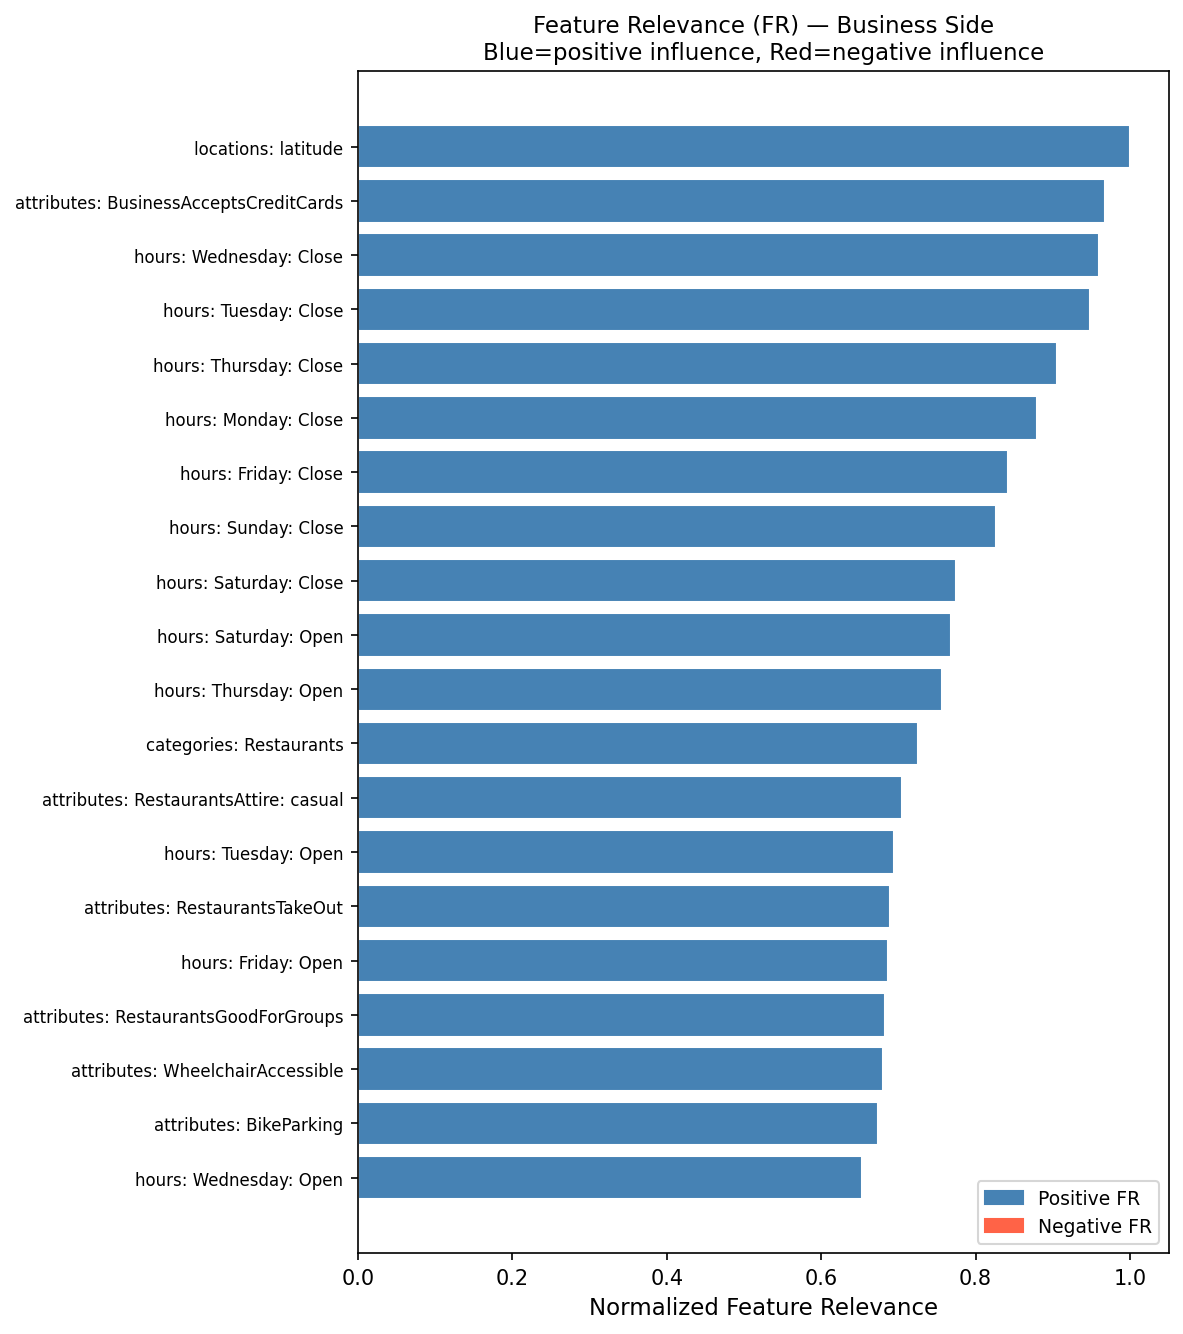

In [9]:
display(Image('figures/fr_user.png'))
display(Image('figures/fr_business.png'))


In [10]:
# Side-by-side: focal vs neighbor FR (signed, for richer analysis)
W1_b    = model.item_gat.W_1.weight.detach().cpu().numpy()
ab_self = model.item_gat.a_self.detach().cpu().numpy()
ab_nb   = model.item_gat.a_nb.detach().cpu().numpy()
omega   = model.item_gat.omega.detach().cpu().numpy()

FR_focal_b    = (ab_self @ W1_b).squeeze()
FR_neighbor_b = omega.sum() * (ab_nb @ W1_b).squeeze()

top20_idx = np.argsort(np.abs(FR_focal_b) + np.abs(FR_neighbor_b))[::-1][:20]
df_fr = pd.DataFrame({
    'feature':         [feature_names_biz[i] for i in top20_idx],
    'FR_focal':        FR_focal_b[top20_idx].round(4),
    'FR_neighbor':     FR_neighbor_b[top20_idx].round(4),
    'FR_combined_abs': (np.abs(FR_focal_b) + np.abs(FR_neighbor_b))[top20_idx].round(4),
}).reset_index(drop=True)
df_fr.index += 1
print("Top-20 Business Feature Relevance:")
print(df_fr.to_string())


Top-20 Business Feature Relevance:
                                   feature  FR_focal  FR_neighbor  FR_combined_abs
1                      locations: latitude    0.0749       0.1831           0.2580
2   attributes: BusinessAcceptsCreditCards    0.0727       0.1770           0.2497
3                  hours: Wednesday: Close    0.0713       0.1765           0.2478
4                    hours: Tuesday: Close    0.0703       0.1743           0.2446
5                   hours: Thursday: Close    0.0677       0.1660           0.2337
6                     hours: Monday: Close    0.0656       0.1614           0.2270
7                     hours: Friday: Close    0.0632       0.1541           0.2173
8                     hours: Sunday: Close    0.0617       0.1514           0.2131
9                   hours: Saturday: Close    0.0579       0.1420           0.1999
10                   hours: Saturday: Open    0.0571       0.1412           0.1983
11                   hours: Thursday: Open    0.0555

---
## Analysis 3: IS Transparency Validation
**Question:** Are NIG attention weights consistent with feature-level similarity?

If NIG weights correlate positively with cosine feature similarity, it means  
the model's attention mechanism is **grounded in observable features** — directly  
supporting the paper's transparency claim (Tintarev & Masthoff 2012).


In [11]:
corr_arr = validate_nig_transparency(
    model, S_b, eb, device,
    sample_nodes=1000
)



──────────────────────────────────────────────────
[Transparency Validation] NIG alpha vs. FR-weighted Feature Similarity
  Nodes analyzed: 778
  Mean Spearman r = 0.1242  (std=0.5646)
  Median Spearman r = 0.2062
  % nodes with positive r = 58.9%
  % nodes with r > 0.3    = 44.7%
  % significant (p<0.05)  = 43.8%
  Interpretation: Weak positive alignment: NIG partially consistent with FR-driven similarity
  Figure saved → figures/transparency_validation.png


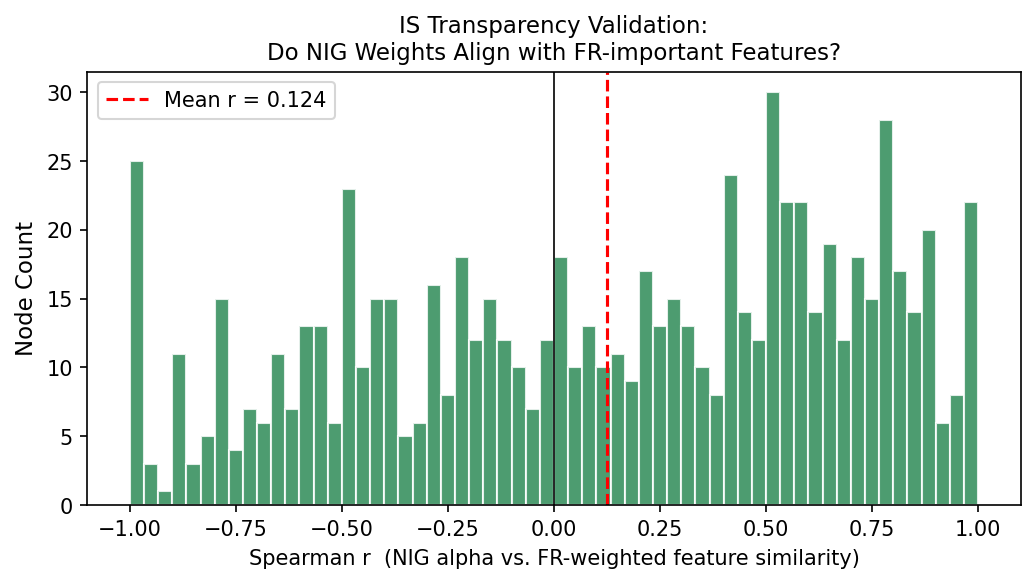

Mean Spearman r:      0.1242
Std:                  0.5646
% positive:           58.9%
% r > 0.3:            44.7%


In [12]:
display(Image('figures/transparency_validation.png'))

# Report-ready statistics
print(f"Mean Spearman r:      {corr_arr.mean():.4f}")
print(f"Std:                  {corr_arr.std():.4f}")
print(f"% positive:           {(corr_arr > 0).mean()*100:.1f}%")
print(f"% r > 0.3:            {(corr_arr > 0.3).mean()*100:.1f}%")


---
## Analysis 4: Case Study — Single Recommendation Explained



In [13]:
# Find a real high-rated pair from test set for a better example
test_df = pd.read_csv('dataset/PA/data.csv')
test_df = test_df[test_df['is_test'] == True]
high_rated = test_df[test_df['rating'] >= 4].head(5)
print("Example high-rated test pairs to use:")
print(high_rated[['user_id', 'item_id', 'rating']].to_string())


Example high-rated test pairs to use:
      user_id  item_id  rating
70        390     5189     5.0
319      2090     4955     5.0
3407     1730     7263     5.0
5019     1267     3568     5.0
6202     3076     6638     5.0


In [14]:
USER_ID = 1267
ITEM_ID = 3568

explain_one_recommendation(
    model,
    user_id=USER_ID,
    item_id=ITEM_ID,
    S_u=S_u, S_b=S_b, eu=eu, eb=eb,
    feature_names_user=feature_names_user,
    feature_names_biz=feature_names_biz,
    device=device,
    top_k_fr=5,
    top_k_nb=3
)



RECOMMENDATION EXPLANATION
  User ID:        1267
  Business ID:    3568
  Predicted Rating: 3.94 / 5.0

[NIG] Top-3 Most Similar Businesses (Neighbor Importance):
  #1  Business 6470  |  α = 0.0806
  #2  Business 2267  |  α = 0.0755
  #3  Business 6027  |  α = 0.0710

[FR] Top-5 Features Driving Neighbor Selection:
  #1  locations: latitude                       FR=0.2580  (positive)
  #2  attributes: BusinessAcceptsCreditCards    FR=0.2497  (positive)
  #3  hours: Wednesday: Close                   FR=0.2478  (positive)
  #4  hours: Tuesday: Close                     FR=0.2446  (positive)
  #5  hours: Thursday: Close                    FR=0.2337  (positive)


---
## Analysis 5: Ablation — NIG vs Uniform Attention
Zero out `a_self` and `a_nb` at inference time → attention becomes uniform.  
Measures how much RMSE degrades without selective neighbor weighting.

> **Note:** This is inference-time ablation (weight zeroing), not full retraining.  
> Full retraining ablation from paper (PA): RMSE = 1.303 (NIG removed).


In [15]:
rmse_nig, rmse_uniform = ablation_nig_vs_uniform(
    model, test_loader, S_u, S_b, eu, eb, device
)



──────────────────────────────────────────────────
[Ablation: NIG vs Uniform Attention]
  RMSE with NIG (trained):   1.3241
  RMSE with Uniform (zeroed): 1.3250
  NIG improvement: +0.07%
  Note: This uses weight-zeroing, not full retraining.
        True ablation RMSE from paper (PA): 1.303 (NIG removed)


In [16]:
ablation_component_contribution(
    model, test_loader, S_u, S_b, eu, eb, device
)



───────────────────────────────────────────────────────
[Ablation: Component Contribution]
  Full model                      RMSE=1.3241  Δ=+0.0000
  Zero user SVD (H_u_4)           RMSE=1.3359  Δ=+0.0118
  Zero item SVD (H_b_4)           RMSE=1.3449  Δ=+0.0209
  Zero user GAT                   RMSE=1.3324  Δ=+0.0083
  Zero item GAT                   RMSE=1.3357  Δ=+0.0116
  Zero all SVD                    RMSE=1.3570  Δ=+0.0329
  Zero all GAT                    RMSE=1.3383  Δ=+0.0143


{'Full model': 1.3240645074723887,
 'Zero user SVD (H_u_4)': 1.3358971332011904,
 'Zero item SVD (H_b_4)': 1.3449483046162,
 'Zero user GAT': 1.3323862313876018,
 'Zero item GAT': 1.3356521778123436,
 'Zero all SVD': 1.35695041773545,
 'Zero all GAT': 1.338325060271169}

In [17]:
print("S_u device:", S_u.device, "shape:", S_u.shape)
print("S_b device:", S_b.device, "shape:", S_b.shape)

S_u device: cuda:0 shape: torch.Size([76864, 36])
S_b device: cuda:0 shape: torch.Size([10966, 1227])


In [18]:
model.eval()
with torch.no_grad():
    H_u_2 = model.user_gat(S_u, eu[0])
    print("GAT user output norm:", H_u_2.norm().item())
    print("H_u_4 norm:", model.H_u_4.weight.norm().item())

GAT user output norm: 312.5232849121094
H_u_4 norm: 11.248245239257812


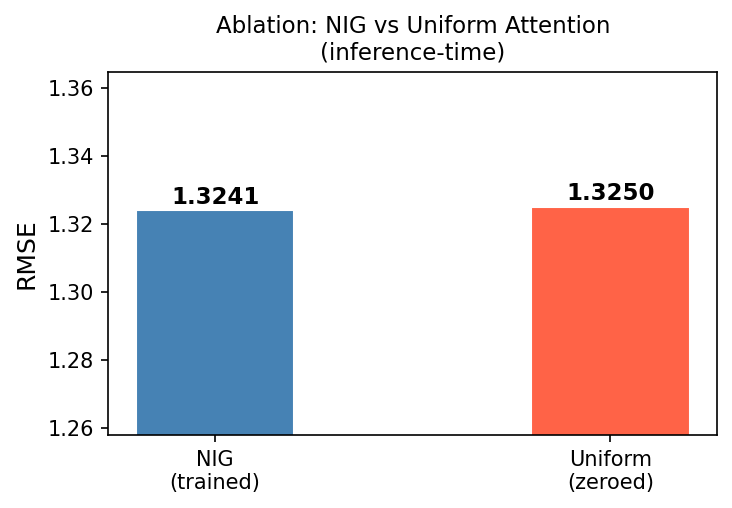

In [19]:
# Visualize ablation comparison
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(['NIG\n(trained)', 'Uniform\n(zeroed)'],
               [rmse_nig, rmse_uniform],
               color=['steelblue', 'tomato'], width=0.4, edgecolor='white')
for bar, val in zip(bars, [rmse_nig, rmse_uniform]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Ablation: NIG vs Uniform Attention\n(inference-time)', fontsize=11)
ax.set_ylim(rmse_nig * 0.95, rmse_uniform * 1.03)
plt.tight_layout()
plt.savefig('figures/ablation_nig.png', dpi=150, bbox_inches='tight')
plt.show()
display(Image('figures/ablation_nig.png'))


---
## Report Summary Table
Copy these numbers into your report.


In [20]:
print("=" * 60)
print("FINDINGS SUMMARY FOR REPORT")
print("=" * 60)

# NIG
u_gini = nig_results['User']['gini'].mean()
b_gini = nig_results['Business']['gini'].mean()
u_ratio = nig_results['User']['top1'].mean() / nig_results['User']['uniform_top1']
b_ratio = nig_results['Business']['top1'].mean() / nig_results['Business']['uniform_top1']

print(f"\n1. NIG Sparsity")
print(f"   User     Gini={u_gini:.3f}  Selectivity={u_ratio:.2f}x over uniform")
print(f"   Business Gini={b_gini:.3f}  Selectivity={b_ratio:.2f}x over uniform")

print(f"\n2. Transparency (NIG vs Feature Similarity)")
print(f"   Mean Spearman r = {corr_arr.mean():.3f}  (% positive: {(corr_arr>0).mean()*100:.1f}%)")

print(f"\n3. Ablation (inference-time)")
print(f"   RMSE with NIG:     {rmse_nig:.4f}")
print(f"   RMSE uniform:      {rmse_uniform:.4f}")
print(f"   Improvement:       {(rmse_uniform-rmse_nig)/rmse_uniform*100:+.2f}%")

print(f"\n4. Figures generated in ./figures/")
for f in sorted(os.listdir('figures')):
    print(f"   {f}")


FINDINGS SUMMARY FOR REPORT

1. NIG Sparsity
   User     Gini=0.175  Selectivity=1.47x over uniform
   Business Gini=0.184  Selectivity=1.48x over uniform

2. Transparency (NIG vs Feature Similarity)
   Mean Spearman r = 0.124  (% positive: 58.9%)

3. Ablation (inference-time)
   RMSE with NIG:     1.3241
   RMSE uniform:      1.3250
   Improvement:       +0.07%

4. Figures generated in ./figures/
   ablation_nig.png
   fr_business.png
   fr_user.png
   nig_sparsity_business.png
   nig_sparsity_user.png
   omega_weights.png
   transparency_validation.png
